# Spectral Clustering Graph Partitioning Bounds

Distance-based clustering like K-Means assumes spherical clusters, failing on complex geometries like concentric rings. Spectral Clustering maps data to graph representations, calculates Laplacian eigenvalues, and partitions coordinate spaces using eigen-projections. This notebook generates concentric circles and visualizes standard K-Means vs. Spectral Clustering.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, SpectralClustering

# Generate synthetic concentric circles (400 samples)
np.random.seed(82)
n_samples = 400

# Inner circle
r_inner = np.random.uniform(0.0, 0.3, n_samples // 2)
theta_inner = np.random.uniform(0, 2*np.pi, n_samples // 2)
X_inner = np.column_stack((r_inner * np.cos(theta_inner), r_inner * np.sin(theta_inner)))

# Outer circle
r_outer = np.random.uniform(0.7, 1.0, n_samples // 2)
theta_outer = np.random.uniform(0, 2*np.pi, n_samples // 2)
X_outer = np.column_stack((r_outer * np.cos(theta_outer), r_outer * np.sin(theta_outer)))

X = np.vstack((X_inner, X_outer))

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df.head(10)



,Feature_1,Feature_2
0,-0.049910,0.065776
1,0.191600,0.008056
2,0.116399,-0.146574
3,-0.103680,0.209122
4,0.007380,0.143244
5,-0.287666,0.006550
6,-0.127540,0.270688
7,-0.087636,0.233874
8,0.050418,-0.034610
9,-0.023737,-0.032462


## Clustering Pipelines Fitting

We fit standard K-Means (which partitions spaces linearly) and Spectral Clustering (using radial basis function RBF kernels with gamma parameter set to 15.0) to segment the coordinates.



In [2]:
# K-Means Pipeline
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(X)

# Spectral Clustering Pipeline
spectral = SpectralClustering(
    n_clusters=2, 
    affinity='rbf', 
    gamma=15.0, 
    random_state=42
)
spectral_labels = spectral.fit_predict(X)

# Compute cluster counts
df['KMeans_Label'] = kmeans_labels
df['Spectral_Label'] = spectral_labels
df.groupby(['KMeans_Label', 'Spectral_Label']).size().unstack(fill_value=0)



Spectral_Label,0,1
KMeans_Label,,
0,188,113
1,12,87


## Clustering Results Subplot Grid

We compare standard K-Means against Spectral Clustering using side-by-side Matplotlib scatter plots to highlight why graph partitioning succeeds on concentric features.



<cell>:19: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



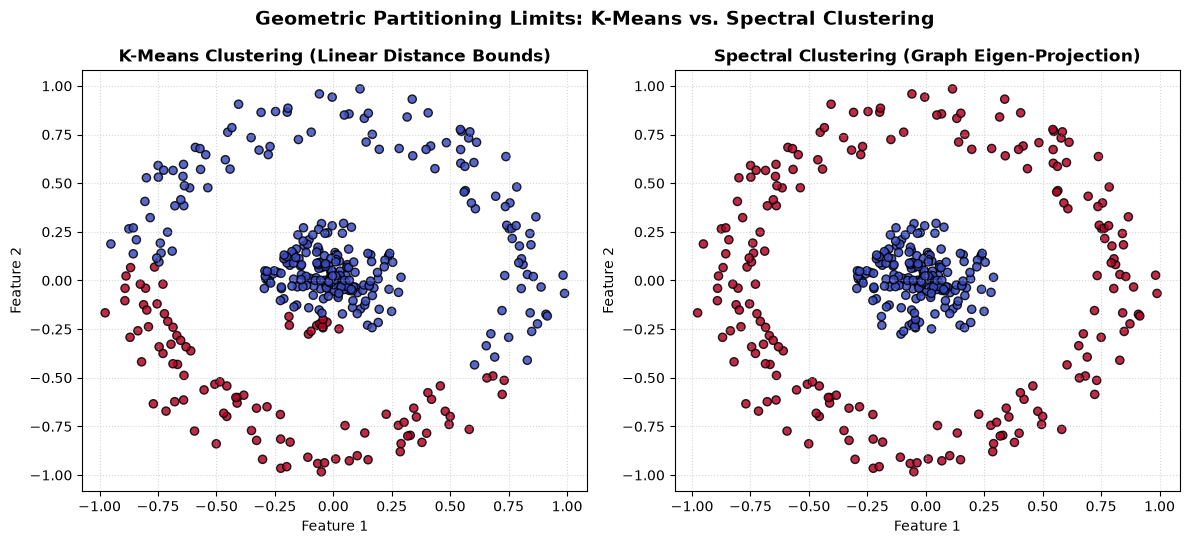

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# 1. K-Means clustering scatter
ax1.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='coolwarm', edgecolors='k', s=35, alpha=0.85)
ax1.set_title('K-Means Clustering (Linear Distance Bounds)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True, linestyle=':', alpha=0.5)

# 2. Spectral clustering scatter
ax2.scatter(X[:, 0], X[:, 1], c=spectral_labels, cmap='coolwarm', edgecolors='k', s=35, alpha=0.85)
ax2.set_title('Spectral Clustering (Graph Eigen-Projection)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Geometric Partitioning Limits: K-Means vs. Spectral Clustering', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
